# Case 1 — Regional Airline × Fuel Price Shock
**Winter Consulting Capstone, Consulting & Analytics Club, IIT Guwahati**

**Business question:** A regional airline connecting Tier-2/3 cities faces a sharp FY25 ATF (jet fuel) price shock. Leadership must pick one primary strategic path over the next 18-24 months:
- **A.** Network Optimization & Dynamic Pricing
- **B.** Government-Backed Route Expansion (UDAN)
- **C.** Structural Operating Model Redesign

**Data note:** the original case is a strategy brief with no dataset attached. `src/data_generation/generate_airline_data.py` builds a route-economics dataset (48 routes × 12 months) from first-principles aviation unit economics — `revenue = seats × load_factor × fare + ancillary`, `fuel_cost = flights × block_hours × fuel_burn_per_hr × ATF_price` — calibrated so pre-shock margins land in the case's stated 'thin but positive' range.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import pandas as pd
pd.set_option('display.max_columns', 20)
from data_generation.generate_airline_data import generate
df = generate()
df.head()

Saved 576 rows -> /home/claude/consulting-portfolio/data/raw/airline_route_performance.csv


,route_id,route,month,seats,weekly_frequency,block_hours,is_udan_route,atf_price_per_litre,load_factor,avg_fare,...,ticket_revenue,ancillary_revenue,udan_subsidy,fuel_cost,lease_crew_cost,airport_handling_cost,total_revenue,total_cost,ebitda,ebitda_margin
0,1,Jamshedpur-Bhubaneswar-R1,2024-04,78,10,1.41,False,88.09,0.733,2499.0,...,6183558.0,521499.0,0.0,10221642.0,556149.0,1004178.0,6705057.0,11781969.0,-5076912.0,-0.7572
1,1,Jamshedpur-Bhubaneswar-R1,2024-05,78,10,1.41,False,94.33,0.729,2682.0,...,6603427.0,705163.0,0.0,10945671.0,507699.0,1115589.0,7308590.0,12568959.0,-5260369.0,-0.7198
2,1,Jamshedpur-Bhubaneswar-R1,2024-06,78,10,1.41,False,89.12,0.778,2533.0,...,6652461.0,950684.0,0.0,10341142.0,535336.0,1367837.0,7603145.0,12244315.0,-4641170.0,-0.6104
3,1,Jamshedpur-Bhubaneswar-R1,2024-07,78,10,1.41,False,91.54,0.699,2494.0,...,5891161.0,689681.0,0.0,10621134.0,467872.0,872930.0,6580843.0,11961936.0,-5381094.0,-0.8177
4,1,Jamshedpur-Bhubaneswar-R1,2024-08,78,10,1.41,False,93.29,0.853,2487.0,...,7170322.0,744284.0,0.0,10824892.0,538795.0,1064045.0,7914605.0,12427732.0,-4513126.0,-0.5702


## 1. Data overview

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
route_id,576.0,NaN,NaN,NaN,24.5,13.86544,1.0,12.75,24.5,36.25,48.0
route,576,48,Jamshedpur-Bhubaneswar-R1,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,576,12,2024-04,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seats,576.0,NaN,NaN,NaN,102.0,22.030493,78.0,90.0,90.0,108.0,138.0
weekly_frequency,576.0,NaN,NaN,NaN,6.854167,3.677369,3.0,3.0,6.0,10.0,14.0
block_hours,576.0,NaN,NaN,NaN,1.527083,0.418504,0.83,1.13,1.53,1.915,2.19
is_udan_route,576,2,False,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atf_price_per_litre,576.0,NaN,NaN,NaN,103.84125,12.380206,82.81,92.2825,101.965,115.2925,127.97
load_factor,576.0,NaN,NaN,NaN,0.708491,0.064808,0.52,0.66375,0.713,0.748,0.907
avg_fare,576.0,NaN,NaN,NaN,4015.647569,1028.364716,2113.0,3217.0,3918.0,4817.0,6687.0


## 2. Fuel price shock vs network profitability
Answers: *how much of current losses are fuel-driven vs structurally embedded?*

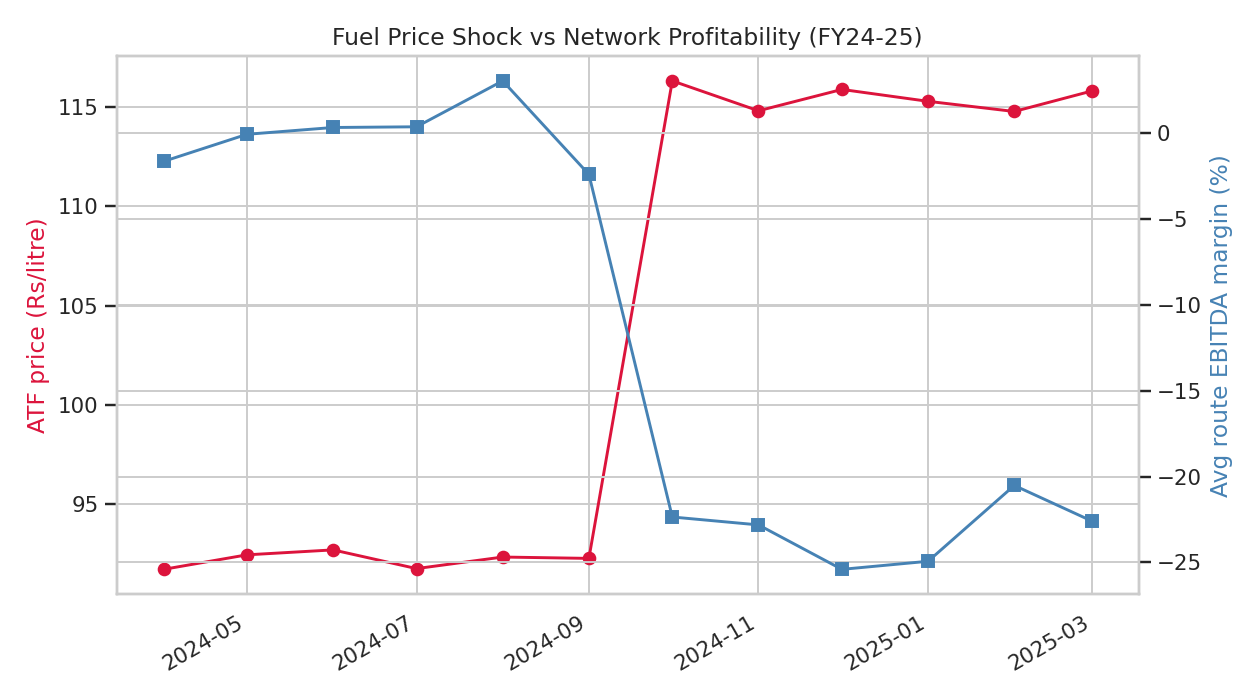

In [3]:
from case1_airline.analysis import load, fig1_fuel_price_vs_margin, fig2_loss_attribution, fig3_route_viability, fig4_scenario_comparison
df = load()
fig1_fuel_price_vs_margin(df)
from IPython.display import Image, display
display(Image('../reports/figures/case1_fuel_price_vs_margin.png'))

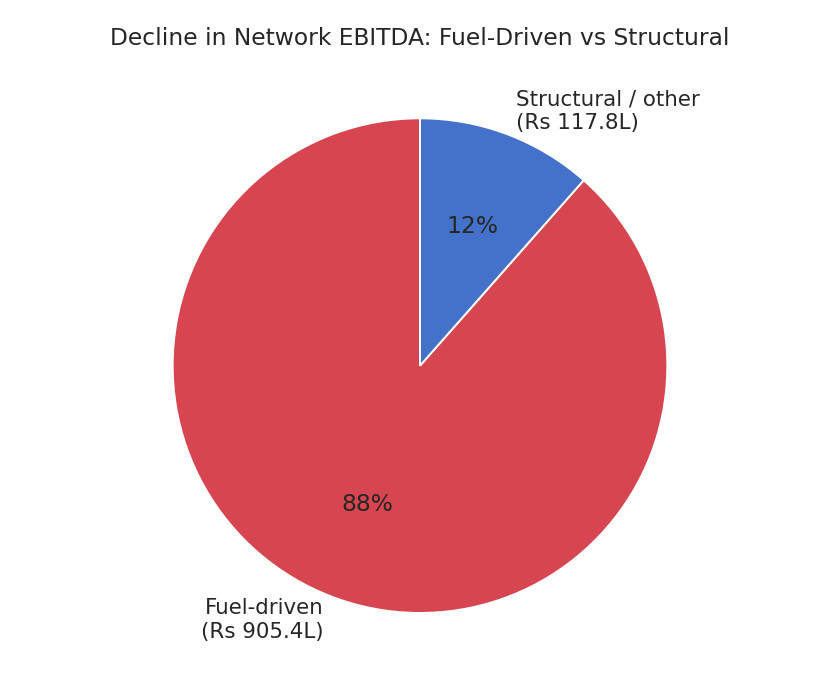

,route_id,pre_fuel_cost,pre_ebitda,post_fuel_cost,post_ebitda,fuel_driven_loss,total_ebitda_decline,structural_component
0,1,1.067040e+07,-5.186717e+06,1.360691e+07,-8.315293e+06,-2.936513e+06,-3.128576e+06,-192063.166667
1,2,1.611649e+06,1.341392e+06,2.044154e+06,8.672895e+05,-4.325050e+05,-4.741027e+05,-41597.666667
2,3,1.838326e+07,-7.071094e+06,2.345834e+07,-1.259061e+07,-5.075080e+06,-5.519512e+06,-444432.666667
3,4,4.251830e+06,-7.401333e+04,5.214589e+06,-1.436118e+06,-9.627585e+05,-1.362104e+06,-399346.000000
4,5,3.515948e+06,-1.282144e+06,4.439984e+06,-1.808926e+06,-9.240367e+05,-5.267818e+05,397254.833333


In [4]:
attribution = fig2_loss_attribution(df)
display(Image('../reports/figures/case1_loss_attribution.png'))
attribution.head()

## 3. Which routes are fundamentally broken vs salvageable?

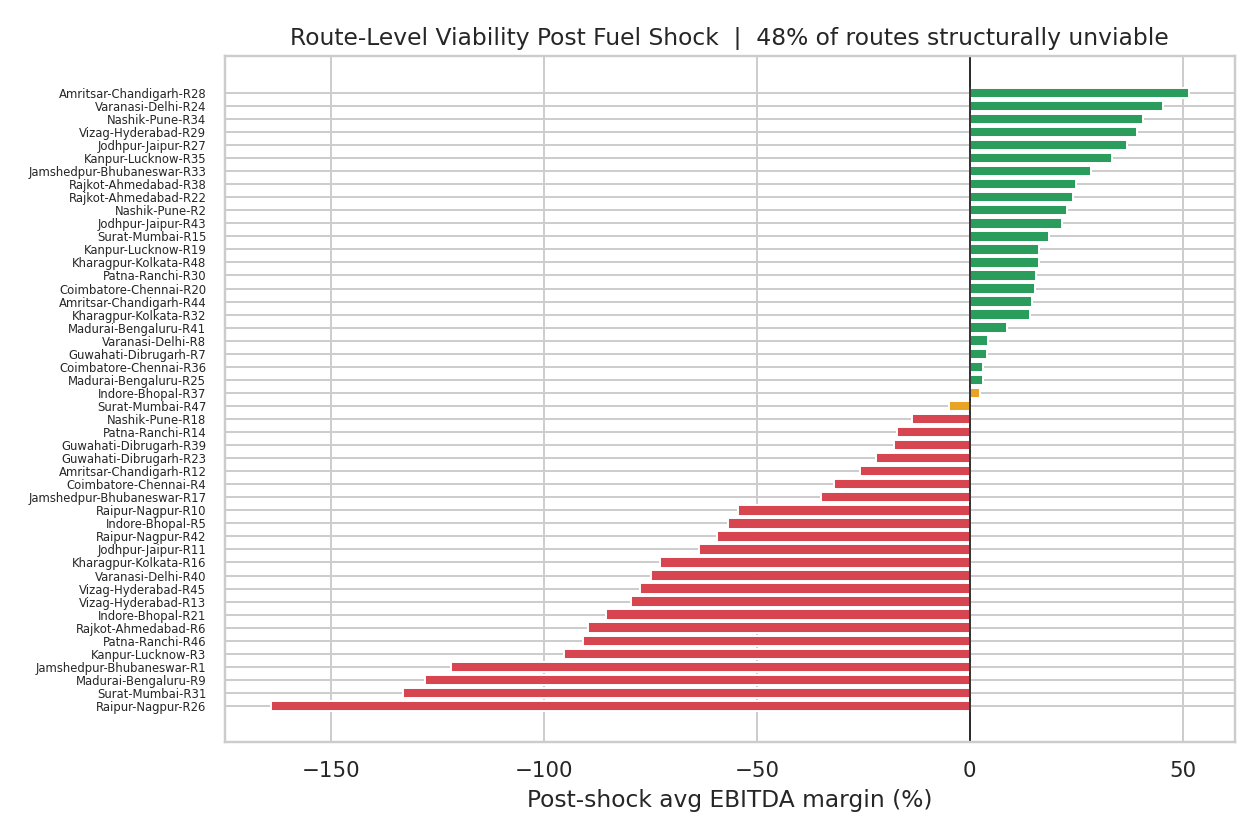

48% of routes structurally unviable post-shock


verdict
Structurally Unviable      23
Healthy                    23
At-Risk (thin/negative)     2
Name: count, dtype: int64

In [5]:
verdicts, pct_unviable = fig3_route_viability(df)
display(Image('../reports/figures/case1_route_viability.png'))
print(f'{pct_unviable:.0%} of routes structurally unviable post-shock')
verdicts['verdict'].value_counts()

## 4. Scenario model: Option A vs B vs C

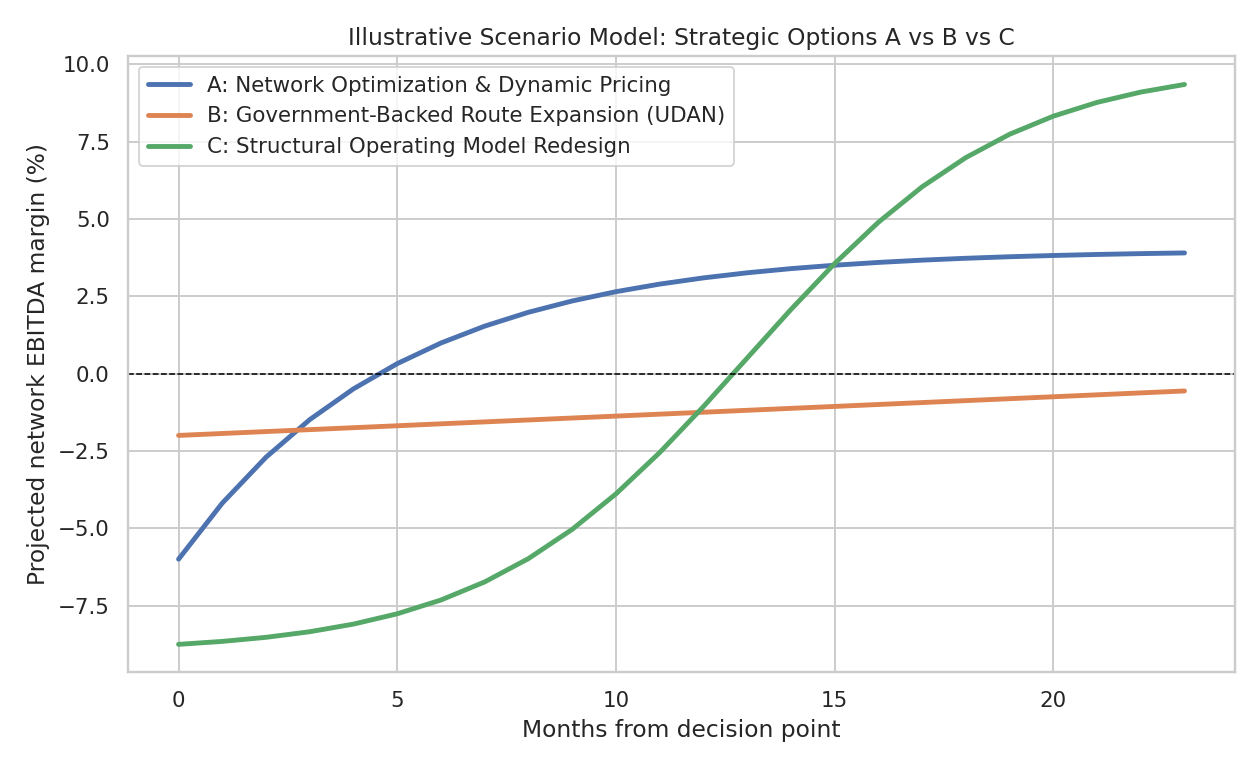

In [6]:
fig4_scenario_comparison()
display(Image('../reports/figures/case1_scenario_comparison.png'))

## 5. Recommendation

**Primary: Option A (Network Optimization & Dynamic Pricing)**, applied to the ~52% of routes that remain healthy or recoverable post-shock — fastest time-to-impact (3-6 months) and directly attacks the largest loss driver (fuel-cost pass-through via yield management).

**Supporting: Option B (selective UDAN expansion)**, targeted only at the structurally-unviable route subset, where guaranteed minimum revenue is the difference between operating and grounding the route — not applied network-wide, since the trade-off (capped pricing, mandatory capacity) would cap margin recovery on routes that don't need it.

**Deferred: Option C (structural redesign)** — correct long-term direction (fleet mix, cost base) but 12-24 month time-to-impact is too slow to be the *primary* response to an 18-24 month decision window; flagged as a parallel workstream, not the headline bet.

**Explicit trade-off accepted:** short-term margin will stay compressed on UDAN routes in exchange for network stability; the airline is consciously *not* pursuing aggressive capacity growth until the core network is fuel-shock-resilient.

**KPIs to track:** CASK, route-level EBITDA margin, cash burn rate.